# Entrenamiento del modelo

In [3]:
import pandas as pd
from xgboost import XGBRegressor
import optuna
from sklearn.multioutput import MultiOutputRegressor
import numpy as np
import matplotlib.pyplot as plt

Cargamos los datos preprocesados y listos para su uso

In [4]:
x_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
x_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')
x_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')
print(y_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11766 entries, 0 to 11765
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   target  11766 non-null  float64
dtypes: float64(1)
memory usage: 92.0 KB
None


In [5]:
cols_cat = ['CARACTER', 'ORIGEN', 'DEPARTAMENTO', 'MUNICIPIO']

# for col in cols_cat:
#     x_train[col] = x_train[col].astype('category')
#     x_test[col]   = x_val[col].astype('category')
#     x_val[col]  = x_test[col].astype('category')
# display(x_train.info())
for col in cols_cat:
    x_train[col] = x_train[col].astype('category')
    x_val[col]   = x_val[col].astype('category').cat.set_categories(x_train[col].cat.categories)
    x_test[col]  = x_test[col].astype('category').cat.set_categories(x_train[col].cat.categories)


In [6]:
modelo_baseline = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    eval_metric='rmse',
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical = True
)

modelo_baseline.fit(x_train,y_train,eval_set=[(x_val,y_val)],verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'rmse'


In [7]:
display(y_val.head())

,target
0,4.58
1,11.07
2,7.59
3,7.67
4,6.20


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_test = modelo_baseline.predict(x_test)

# y_pred_val = np.clip(y_pred_val,0,100)

rmse_s1 = np.sqrt(mean_squared_error(y_test, y_pred_test))

mae_s1 = mean_absolute_error(y_test, y_pred_test)

print(f"Semestre 1 — RMSE: {rmse_s1:.2f} | MAE: {mae_s1:.2f}")


Semestre 1 — RMSE: 9.70 | MAE: 4.17


Realiazamos etapa de Tunning del modelo XGboosting para ver si es mejor que el anterior usando la libreria Optuna, que es más eficiente y rápida que las busquedas de scikit learn, pero usa la técnica de bayesian grid. 

In [9]:


def objective(trial):
    params = {
        'objective':'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_estimators': 1000,
        'enable_categorical': True,
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.4),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'early_stopping_rounds':50
    }

    modelo = XGBRegressor(**params)
    
    modelo.fit(
        x_train, y_train,
        eval_set=[(x_val, y_val)],
        verbose=False
    )

    y_pred = modelo.predict(x_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(f"Mejor RMSE: {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

[I 2026-06-10 09:00:15,951] A new study created in memory with name: no-name-f6b232fe-7ef9-45f4-a7a7-d5f021b2020e
[I 2026-06-10 09:00:16,028] Trial 0 finished with value: 10.672288922929898 and parameters: {'max_depth': 3, 'learning_rate': 0.37139152352319393, 'subsample': 0.9268278601898299, 'colsample_bytree': 0.7096655180008253, 'gamma': 4.473787300337498, 'reg_lambda': 2.863138343511231, 'reg_alpha': 3.948623717643339}. Best is trial 0 with value: 10.672288922929898.
[I 2026-06-10 09:00:16,100] Trial 1 finished with value: 10.269237051225266 and parameters: {'max_depth': 2, 'learning_rate': 0.15196356629564467, 'subsample': 0.7139279520195642, 'colsample_bytree': 0.7537089282078131, 'gamma': 1.645198903268762, 'reg_lambda': 4.91290039026075, 'reg_alpha': 2.2407441233947925}. Best is trial 1 with value: 10.269237051225266.
[I 2026-06-10 09:00:16,306] Trial 2 finished with value: 10.38348960534354 and parameters: {'max_depth': 6, 'learning_rate': 0.3593175169671239, 'subsample': 0.99

Mejor RMSE: 9.5071
Mejores hiperparámetros: {'max_depth': 2, 'learning_rate': 0.2965533416281506, 'subsample': 0.9989366036484563, 'colsample_bytree': 0.6777612889001697, 'gamma': 4.059806564274843, 'reg_lambda': 7.321281858894827, 'reg_alpha': 2.606575038433628}


In [10]:
best_params = study.best_params
best_params.update({
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 42,
    'n_estimators': 1000,
    'enable_categorical': True,
    'early_stopping_rounds': 50
})

modelo_final = XGBRegressor(**best_params)
modelo_final.fit(x_train, y_train,
                 eval_set=[(x_val, y_val)],
                 verbose=False)

y_pred_test = np.clip(modelo_final.predict(x_test), 0, 100)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test):.2f}")


Test RMSE: 9.51
Test MAE:  4.16


ORIGEN          0.000000
semestre        0.005865
MUNICIPIO       0.046256
CARACTER        0.055228
lag4            0.077773
DEPARTAMENTO    0.094382
lag3            0.149769
lag2            0.160761
lag1            0.409967
dtype: float32


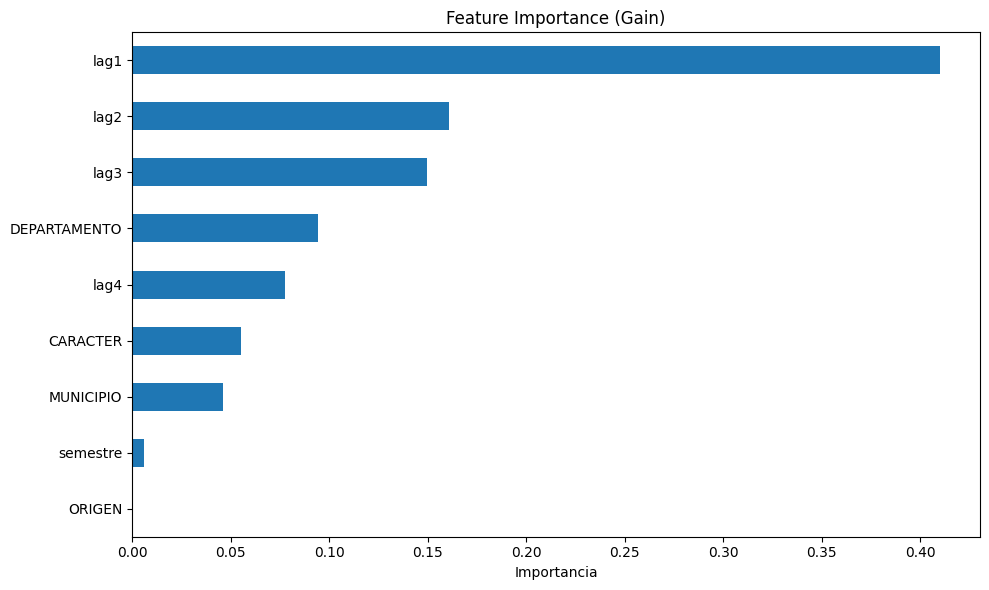

In [11]:
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True)
print(importancias)
importancias.plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance (Gain)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()